In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [3]))
print('using GPU %s' % ','.join(map(str, [3])))

import torch
import torch.optim as optim
from thop import profile, clever_format

import csv
import time
import numpy as np
import json
from datetime import datetime
import matplotlib.pyplot as plt
plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe_D, data_reader
from loadData.split_data import HyperX
from loadData.dataAugmentation import DataAugmentationDINO

from utils import util, trainer, KNN, SVM, tester
from models import model, vision_transformer, automaticWeightedLoss, vitgcn_model

using GPU 3


In [2]:
args = opt.get_args()
# args.dataset_name = "IndianPines"
# args.dataset_name = "PaviaU"
args.dataset_name = "Houston_2018"

args.backbone = "vit"
args.local_crops_number = 0
args.patch_size = 25
args.randomCrop = 23
args.components = 10
args.split_type = "disjoint"
args.lambda_contra = 0
args.lambda_super = 1
args.awl = True

args.result_dir = os.path.join("/home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/" + 
                    datetime.now().strftime("%m-%d-%H-%M-vit_D8"))
print(args.result_dir)

# 加载已有权重路径
# args.result_dir = "/home/liuquanwei/code/DMVL_joint_MNDIS/results_final/08-09-17-05-vit_D8"
if not os.path.exists(args.result_dir):
    os.mkdir(args.result_dir)
with open(args.result_dir + '/args.json', 'w') as fid:
    json.dump(args.__dict__, fid, indent=2)

/home/liuquanwei/code/DMVL_joint_MNDIS/results_ablation/10-18-10-49-vit_D8


In [3]:
# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, test_gt, data_gt = data_pipe_D.get_data(args)
transform = DataAugmentationDINO(args.randomCrop)

train_dataset = HyperX(img1, img2, data_gt, transform=transform, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)
memory_dataset = HyperX(img1, img2, train_gt, transform=None, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)
test_dataset = HyperX(img1, img2, test_gt, transform=None, patch_size=args.patch_size, flip_augmentation=False, 
                        radiation_augmentation=False, mixture_augmentation=False, 
                        remove_zero_labels=args.remove_zero_labels)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)
memory_loader = torch.utils.data.DataLoader(memory_dataset,batch_size=args.batch_size,shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset,batch_size=args.batch_size,shuffle=False)

class_num = np.max(train_gt)
print(class_num, train_gt.shape), len(train_loader.dataset)

halving_line 24
(625, 2408, 48) (625, 2408, 10) (625, 2408, 10) (625, 2408)
(625, 2408, 48) (625, 2408, 10) (625, 2408, 10) (625, 2408)
(625, 2408, 48) (625, 2408, 10) (625, 2408, 10) (625, 2408)
split_type:  disjoint 
train_ratio:  1
split_type:  disjoint 
train_ratio:  1
split_type:  disjoint 
train_ratio:  1
(625, 2408) (625, 2408)
20 (625, 2408)


(None, 504712)

In [4]:
# for x, y, z in train_loader:
#     print("x.shape, y.shape", x[0].shape)

# model

In [5]:
# model setup and optimizer config
# encoder = model.Model_base(args.components).cuda()
encoder = vision_transformer.vit_hsi(args.components, args.randomCrop).cuda()
# encoder = vision_transformer.vit_small(args.components, args.randomCrop).cuda()
contra_head = model.DINOHead(args.feature_dim).cuda()
super_head = model.FDGC_head(args.feature_dim, class_num=class_num).cuda()
awl = automaticWeightedLoss.AutomaticWeightedLoss(2).cuda()
net = util.MultiCropWrapper(encoder).cuda()
# print(model)
flops, params = profile(net, inputs=(torch.randn(1, args.components, 
                                                args.patch_size, args.patch_size).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

# contra_head
flops, params = profile(contra_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

# super_head
flops, params = profile(super_head, inputs=(torch.randn(1, args.feature_dim).cuda(),))
flops, params = clever_format([flops, params])
print('# Model Params: {} FLOPs: {}'.format(params, flops))

criterion = torch.nn.CrossEntropyLoss()
params = list(super_head.parameters()) + list(contra_head.parameters()) + \
                list(net.parameters()) + list(awl.parameters())
optimizer = optim.Adam(params, lr=1e-3, weight_decay=1e-6, amsgrad=True)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = args.epochs, 
                            eta_min = 1e-8, last_epoch = -1)

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.normalization.LayerNorm'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
# Model Params: 534.11K FLOPs: 19.69M
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
# Model Params: 65.66K FLOPs: 66.05K
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.dropout.Dropout'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm1d'>.
[INFO] Register zero_ops() for <clas

# 训练前加载权重

In [18]:
# args.resume = os.path.join(args.result_dir, "joint_oa_model.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

In [19]:
best_loss = 999
best_acc = 0
train_losses = []
loss_contras = []
loss_supers = []

total_train_time = time.time()
for epoch in range(epoch_start, args.epochs):
###################################################################->>>>>>>>>
    start_time = time.time()
    train_loss, loss_contra, loss_super, linear_tra,  linear_tea \
                        = trainer.train(epoch, net, contra_head, super_head, awl, 
                                    train_loader, memory_loader, test_loader, optimizer, args)
    train_losses.append(train_loss)
    loss_contras.append(loss_contra)
    loss_supers.append(loss_super)
    scheduler.step()
    train_time = time.time() - start_time
###################################################################<<<<<<<<<<<<-
    
    # # validation
    if epoch % args.log_interval == 0:
        start_time = time.time()
        KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net,memory_loader,test_loader,class_num,train_gt,args)
        Knn_time = time.time() - start_time
        # knn_plot_figure.visulation(net, gt, memory_loader, data_loader, class_num, KNNOA, args)
        
    # if epoch == args.epochs - 1:
    #     start_time = time.time()
    #     SVMCA, SVMOA, SVMAA, SVMkA = SVM_multi.test(net, memory_loader, test_loader, class_num, args)
    #     SVM_time = time.time() - start_time
    #     # svm_plot_figure.visulation(net, gt, memory_loader, data_loader, SVMOA, args)

    #     with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
    #         row=[["epoch", epoch, 
    # ###################################################################->>>>>>>>>
    #             "loss", train_loss, 
    #             "loss_contra", loss_contra,
    #             "loss_super", loss_super,
    #             # "linear_tracc", linear_tra,
    #             "linear_teacc", linear_tea,
    #             "train_time", round(train_time, 2),
    #             '\n',
    # ###################################################################<<<<<<<<<<<<-
    #             # "KNN_CA", np.round(KNNCA, 2),
    #             "KNN_OA", np.round(KNNOA, 2),
    #             "KNN_AA", np.round(KNNAA, 2),
    #             "KNN_KA", np.round(KNNKA, 2),
    #             "KNN_Time", round(Knn_time, 2),
    #             '\n',
    #             "SVM_CA", np.round(SVMCA, 2),
    #             "SVM_OA", np.round(SVMOA, 2),
    #             "SVM_AA", np.round(SVMAA, 2),
    #             "SVM_KA", np.round(SVMkA, 2),
    #             "SVM_time", round(SVM_time, 2)
    #             ]]
    #         write=csv.writer(f)
    #         for i in range(len(row)):
    #             write.writerow(row[i])
    # else:
    with open(os.path.join(args.result_dir, "log.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
###################################################################->>>>>>>>>
            "loss", train_loss, 
            "loss_contra", loss_contra,
            "loss_super", loss_super,
            # "linear_tracc", linear_tra,
            "linear_teacc", linear_tea,
            "train_time", round(train_time, 2),
            '\n',
###################################################################<<<<<<<<<<<<-
            # "KNN_CA", np.round(KNNCA, 2),
            "KNN_OA", np.round(KNNOA, 2),
            "KNN_AA", np.round(KNNAA, 2),
            "KNN_KA", np.round(KNNKA, 2),
            "KNN_Time", round(Knn_time, 2),
            '\n',
            # "SVM_CA", np.round(SVMCA, 2),
            # "SVM_OA", np.round(SVMOA, 2),
            # "SVM_AA", np.round(SVMAA, 2),
            # "SVM_KA", np.round(SVMkA, 2),
            # "SVM_time", round(SVM_time, 2)
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])
####################################################################->>>>>>>>>
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save({
                "epoch": epoch,
                "base": net.state_dict(),
                "contra_head": contra_head.state_dict(),
                "head": super_head.state_dict(),
                "optimizer": optimizer.state_dict()}, 
                os.path.join(args.result_dir, "joint_model_loss.pth"))
        
    if KNNOA > best_acc:
        best_acc = KNNOA
        torch.save({
                "epoch": epoch,
                "base": net.state_dict(),
                "contra_head": contra_head.state_dict(),
                "head": super_head.state_dict(),
                "optimizer": optimizer.state_dict()}, 
                os.path.join(args.result_dir, "joint_model_oa.pth"))
###################################################################<<<<<<<<<<<<-
total_time = time.time() - total_train_time

torch.save({
        "epoch": epoch,
        "base": net.state_dict(),
        "contra_head": contra_head.state_dict(),
        "head": super_head.state_dict(),
        "optimizer": optimizer.state_dict()}, 
os.path.join(args.result_dir, "joint_model_last.pth"))

# 保存最优结果

In [20]:
args.resume = os.path.join(args.result_dir, "joint_model_oa.pth")
# args.resume = os.path.join(args.result_dir, "joint_model_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    super_head.load_state_dict(checkpoint['head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

for k in range(5, 6):
    args.knn_k = k
    start_time = time.time()
    KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net, memory_loader, \
                                test_loader, class_num, train_gt, args)
    print("KNNOA", KNNOA)
    Knn_time = time.time() - start_time

    # linear 精度
    start_time = time.time()
    test_losses, test_preds, correct, targets = \
        tester.linear_test(net, super_head, criterion, test_loader, args)
    classification, kappa = tester.get_results(test_preds, targets)
    Linear_time = time.time() - start_time

    # print(KNNOA)
    with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
        row=[["epoch", epoch, 
            "KNN_K", args.knn_k,
            "KNN_CA", np.round(KNNCA, 2),
            "KNN_OA", np.round(KNNOA, 2),
            "KNN_AA", np.round(KNNAA, 2),
            "KNN_KA", np.round(KNNKA, 2),
            "KNN_Time", round(Knn_time, 2),
            "\nclassification\n", classification,
            "\nkappa", kappa,
            "Linear_time", np.round(Linear_time, 2),
            "total_time", round(total_time, 2)
            ]]
        write=csv.writer(f)
        for i in range(len(row)):
            write.writerow(row[i])

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results_final/08-09-17-05-vit_D8/joint_model_loss.pth
KNNOA 74.38961370378641
Accuracy: 348644/470235 (74.14%)



# 绘图

In [21]:
# args.resume = os.path.join(args.result_dir, "joint_model_oa.pth")
# if args.resume != '':
#     checkpoint = torch.load(args.resume)
#     net.load_state_dict(checkpoint['base'], strict=False)
#     epoch_start = checkpoint['epoch'] + 1
#     print('Loaded from: {}'.format(args.resume))
# else:
#     epoch_start = 0

# _, groundTruth = data_reader.load_data(args.dataset_name, path_data=args.path_data, type_data="Houston")

# args.remove_zero_labels = False
# args.train_ratio = 1
# img1, img2, train_gt, test_gt, data_gt = data_pipe_D.get_data(args)

# # create dataloader
# data_dataset = HyperX(img1, img2, data_gt, transform=None, 
#                        patch_size=args.patch_size, 
#                        flip_augmentation=False, 
#                         radiation_augmentation=False, mixture_augmentation=False, 
#                         remove_zero_labels=args.remove_zero_labels)
# data_loader = torch.utils.data.DataLoader(data_dataset, batch_size=args.batch_size, \
#                                            shuffle=False, drop_last=False)

# KNNCA, KNNOA, KNNAA, KNNKA = KNN.test(net, memory_loader, data_loader, class_num, \
#                                       groundTruth, args, visulation=True)

# 画 loss 曲线

In [22]:
# # args.plot_loss_curve = True
# if args.plot_loss_curve:
#     fig = plt.figure()
#     plt.plot(range(args.epochs), train_losses, color='blue')
#     plt.plot(range(args.epochs), loss_contras, color='red')
#     plt.plot(range(args.epochs), loss_supers, color='pink')

#     # test_counter 是先定义好的，test——losses 训练一轮记录一次
#     # plt.scatter(test_counter, test_losses, color='red')
#     plt.legend(['train_losses', 'loss_contras', 'loss_supers'], loc='upper right')
#     plt.xlabel('number of training examples seen')
#     plt.ylabel('negative log likelihood loss')
#     plt.show()

# TSNE

In [11]:
with torch.no_grad():
    for idx_o, (data, _, target) in enumerate(test_loader):
        target = target - 1
        data = data.to(args.device)
        
        output = super_head(net(data))
        target = target.to(args.device)

        for idx, _ in enumerate(output.cpu().numpy()):
            # print(output.cpu().numpy().shape)
            if idx == 0 and idx_o == 0:
                list_output = output.cpu().numpy()[idx]
                list_target = target.cpu().numpy()[idx]
            # print(list_output.shape, list_target.shape)

            if idx < 100:
                list_output = np.vstack((list_output, output.cpu().numpy()[idx]))
                list_target = np.append(list_target, target.cpu().numpy()[idx])

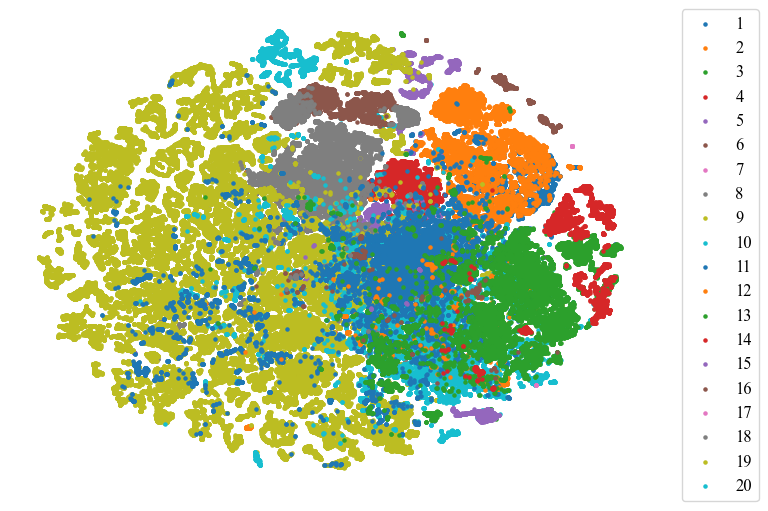

In [12]:
from sklearn.manifold import TSNE
tsne = TSNE()

out = tsne.fit_transform(list_output)
fig, ax = plt.subplots()
ax.set_axis_off()
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# fig.set_size_inches(label.shape[1] * scale / dpi, label.shape[0] * scale / dpi)
plt.gca().xaxis.set_major_locator(plt.NullLocator())
plt.gca().yaxis.set_major_locator(plt.NullLocator())
plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)

label = ["Broccoli-weeds-1","Broccoli-weeds-2","Fallow","Fallow-rough-plow",
         "Fallow-smooth","Stubble","Celery","Grapes-untrained",
         "Soil-senesced-develop","Corn-weeds","Lettuce-4wk","Lettuce-5wk",
         "Lettuce-6wk","Lettuce-7wk","Vinyard-untrained",
         "Vinyard-vertical-trellis"]
for i in range(class_num):
    indices = list_target  == i
    x, y = out[indices].T
    # plt.scatter(x, y, s=5, label=label[i])
    plt.scatter(x, y, s=5, label=str(i+1))
plt.legend(loc=2,bbox_to_anchor=(1.05,1.0),borderaxespad = 0., fontsize=12)
plt.savefig(args.result_dir  + '/tsneFull' + '.png', dpi=400, bbox_inches="tight")

# 线性测试

In [11]:
head = model.FDGC_head(in_dim=args.feature_dim, class_num=class_num).to(args.device)

args.resume = os.path.join(args.result_dir, "joint_model_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['base'], strict=False)
    head.load_state_dict(checkpoint['head'], strict=False)
    # epoch_start = checkpoint['epoch'] + 1
    print('Loaded from: {}'.format(args.resume))
else:
    epoch_start = 0

params = list(net.parameters()) + list(head.parameters())
optimizer = torch.optim.Adam(params, lr=3e-4)
# optimizer = optim.Adam(params, lr=1e-1, weight_decay=1e-6, amsgrad=True)
criterion = torch.nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.MultiStepLR(
                optimizer, milestones=[args.epochs // 2, 
                (5 * args.epochs) // 6], gamma=0.1)

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results/09-23-14-56-vit_D8/joint_model_loss.pth


In [12]:
for name, param in net.named_parameters():
    param.requires_grad = False
    # print(param.requires_grad)      

In [13]:
def train(net, head, max_epoch, memory_loader, test_loader, criterion, optimizer, scheduler):
  best_loss = 9999
  best_acc = 0
  train_losses = []

  for epoch in range(0, max_epoch):
    net.train()
    head.train()
    test_preds = []
    train_correct = 0
    test_correct = 0
    tic1 = time.time()
    
    for data, _, target in memory_loader:
      target = target -1
      data = data.to(args.device)
      target = target.to(args.device)
      optimizer.zero_grad()
      output = head(net(data))
      loss = criterion(output, target)
      loss.backward()
      optimizer.step()
      pred = output.data.max(1, keepdim=True)[1]
      train_correct += pred.eq(target.data.view_as(pred)).sum()

    scheduler.step()
    train_losses.append(loss.cpu().detach().item())
    train_accuracy = 100. * train_correct / len(memory_loader.dataset)
    training_time = time.time() - tic1

    # validation 
    tic2 = time.time()
    if epoch % args.log_interval == 0:
      net.eval()
      head.eval()
      with torch.no_grad():
        for data, _, target in test_loader:
          target = target - 1 
          data, target= data.to(args.device), target.to(args.device)
          output = head(net(data))
          test_pred = output.data.max(1, keepdim=True)[1]
          test_correct += test_pred.eq(target.data.view_as(test_pred)).sum()
          test_label = torch.argmax(output, dim=1)
          test_preds.append(test_label.cpu().numpy().tolist())
      test_accuracy = 100. * test_correct / len(test_loader.dataset)
    

      if loss.item() < best_loss:
        best_loss = loss.item()
        torch.save({"epoch": epoch,
                    "model": net.state_dict(),
                    "head": head.state_dict(),
                    "optimizer": optimizer.state_dict()},
                    args.result_dir + "/best_model_loss.pth")
        print("save best loss weights at epoch", epoch)

      # 按照道理说，这里应该用train_acc, 但是为了精度，我选择 test_acc
      if test_accuracy.item() > best_acc:
        best_acc = test_accuracy.item()
        torch.save({"epoch": epoch,
                    "model": net.state_dict(),
                    "head": head.state_dict(),
                    "optimizer": optimizer.state_dict()},
                    args.result_dir + "/best_model_acc.pth")
        print("save best acc weights at epoch", epoch)
    test_time = time.time() - tic2

    print("epoch", epoch,
          "loss", round(loss.item(), 6), 
          "test_accuracy", round(test_accuracy.item(), 4))

    # with open(os.path.join(args.result_dir, "linear.csv"), 'a+', encoding='gbk') as f:
    #     row=[["epoch", epoch, 
    #           "train num", args.train_num,
    #             "loss", round(loss.item(), 4), 
    #             "train acc", round(train_accuracy.item(), 4),
    #             "test acc", round(test_accuracy.item(), 4),
    #             "training time", round(training_time, 4),
    #             "test time", round(test_time, 4)
    #             ]]
    #     write=csv.writer(f)
    #     for i in range(len(row)):
    #         write.writerow(row[i])
  return train_losses, train_accuracy

total_tune_time = time.time()
train_losses, train_accuracy = train(net, head, args.tune_epochs, 
                memory_loader, test_loader, criterion, optimizer, scheduler)
total_tune_time = time.time() - total_tune_time

save best loss weights at epoch 0
save best acc weights at epoch 0
epoch 0 loss 0.005025 test_accuracy 71.4879
epoch 1 loss 0.002095 test_accuracy 71.4879
epoch 2 loss 0.000941 test_accuracy 71.4879
epoch 3 loss 0.000629 test_accuracy 71.4879
epoch 4 loss 0.00497 test_accuracy 71.4879
epoch 5 loss 0.001595 test_accuracy 71.4879
epoch 6 loss 0.000372 test_accuracy 71.4879


In [ ]:
args.resume = os.path.join(args.result_dir, "best_model_acc.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    net.load_state_dict(checkpoint['model'], strict=False)
    head.load_state_dict(checkpoint['head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0
    
test_losses, test_preds, correct, targets = \
    tester.linear_test(net, head, criterion, test_loader, args)
classification, kappa = tester.get_results(test_preds, targets)

# print(KNNOA)
with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["epoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        "total_tune_time", round(total_tune_time, 2)
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

Loaded from: /home/liuquanwei/code/DMVL_joint_MNDIS/results/09-23-10-23-vit_D8/best_model_acc.pth epoch 1
Accuracy: 344531/470235 (73.27%)

